# 8. Love numbers with the radial solver

Tidal Love numbers summarize how a body responds to a tidal potential: `k` scales the induced gravity
potential, `h` the radial (vertical) surface displacement, and `l` the tangential displacement. They
follow from integrating the interior structure, which is what the 1D **radial solver** does: given each
layer's density, complex moduli, and type, it integrates the six-component `y` system from the center
to the surface and reads the Love numbers off the surface boundary condition.

This notebook computes Love numbers for a layered terrestrial world and shows how they change with the
two main modeling assumptions: **compressible vs incompressible**, and **static vs dynamic** (whether
the body's own inertia is included). The solver has two engines: a **shooting** integrator for general
compressible interiors, and a **propagator matrix** for the incompressible homogeneous limit, which we
check against a classical analytic result.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G
from TidalPy.RadialSolver_x import radial_solver
from TidalPy.rheology_x import Maxwell, Elastic

def first(a):
    return complex(np.atleast_1d(a)[0])

def solve_layers(radius, density, cbulk, cshear, freq, bulk_density, types, is_static,
                 is_incompressible, upper_radii, degree_l=2, use_prop_matrix=False):
    "Run the radial solver and return (k, h, l, success)."
    sol = radial_solver(radius, density, cbulk, cshear, freq, bulk_density,
                        types, is_static, is_incompressible, upper_radii,
                        degree_l=degree_l, solve_for=("tidal",), use_prop_matrix=use_prop_matrix)
    return first(sol.k), first(sol.h), first(sol.l), sol.success


## A two-layer terrestrial world

A dense stiff core under a rocky Maxwell mantle, forced at a one-day tidal period. The interface radius appears twice in the radius array, once as the top of the core and once as the base of the mantle. Solved with the shooting method (compressible), the Love numbers land near Earth's values.

In [2]:
R = 6.371e6
R_core = 3.48e6
freq = 2.0 * np.pi / 86400.0     # one-day forcing

n_core = n_mantle = 80
radius = np.concatenate([np.linspace(0.0, R_core, n_core), np.linspace(R_core, R, n_mantle)])
in_core = np.arange(radius.size) < n_core

density = np.where(in_core, 10000.0, 4500.0)
bulk_density = 5510.0
shear = np.where(in_core, Elastic().calc_complex_modulus(200e9, 1e40, freq),
                          Maxwell().calc_complex_modulus(80e9, 1e21, freq))
bulk = np.where(in_core, 300.0e9 + 0j, 200.0e9 + 0j)
upper = np.array([R_core, R])
types = ("solid", "solid")

k, h, l, ok = solve_layers(radius, density, bulk, shear, freq, bulk_density,
                           types, (False, False), (False, False), upper)
print(f"success = {ok}")
print(f"k2 = {k.real:+.4f} {k.imag:+.4f}j")
print(f"h2 = {h.real:+.4f}")
print(f"l2 = {l.real:+.4f}")


success = True
k2 = +0.2746 -0.0000j
h2 = +0.5474
l2 = +0.1681


## Compressible vs incompressible

For a homogeneous sphere the incompressible limit has a classical closed form (the Kelvin result), `k2 = 3/2 / (1 + 19 mu / (2 rho g R))`. The propagator-matrix engine reproduces it, and allowing compressibility (shooting) raises `k2` a little because the interior can also change volume.

In [3]:
N = 120
r_h = np.linspace(0.0, R, N)
rho_h = np.full(N, bulk_density)
mu_h = Elastic().calc_complex_modulus(80.0e9, 1e40, freq)
shear_h = np.full(N, mu_h)
bulk_h = np.full(N, 200.0e9 + 0j)

k_incomp, _, _, ok_i = solve_layers(r_h, rho_h, bulk_h, shear_h, freq, bulk_density,
                                    ("solid",), (True,), (True,), np.array([R]), use_prop_matrix=True)
k_comp, _, _, ok_c = solve_layers(r_h, rho_h, bulk_h, shear_h, freq, bulk_density,
                                  ("solid",), (True,), (False,), np.array([R]))

g_surf = G * bulk_density * (4.0 / 3.0) * np.pi * R
k_analytic = 1.5 / (1.0 + 19.0 * 80.0e9 / (2.0 * bulk_density * g_surf * R))

print(f"incompressible (propagator matrix): k2 = {k_incomp.real:.5f}")
print(f"incompressible (analytic Kelvin)  : k2 = {k_analytic:.5f}")
print(f"compressible   (shooting)         : k2 = {k_comp.real:.5f}")


incompressible (propagator matrix): k2 = 0.46788
incompressible (analytic Kelvin)  : k2 = 0.46788
compressible   (shooting)         : k2 = 0.47556


## Static vs dynamic

The *dynamic* solution keeps the body's own inertia; the *static* solution drops it. Sweeping the forcing period shows they agree at the long periods typical of tides, and separate only toward very short periods, where inertia begins to matter. In other words, the static approximation is excellent across the tidal regime.

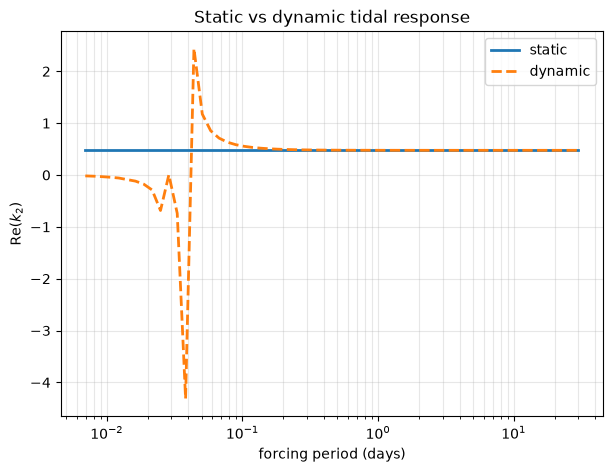

In [4]:
periods_s = np.logspace(np.log10(600.0), np.log10(30.0 * 86400.0), 60)   # 10 min to 30 days
k_static, k_dynamic = [], []
for p in periods_s:
    w = 2.0 * np.pi / p
    mu = Maxwell().calc_complex_modulus(80.0e9, 1.0e21, w)
    sh = np.full(N, mu)
    ks, *_ = solve_layers(r_h, rho_h, bulk_h, sh, w, bulk_density, ("solid",), (True,),  (False,), np.array([R]))
    kd, *_ = solve_layers(r_h, rho_h, bulk_h, sh, w, bulk_density, ("solid",), (False,), (False,), np.array([R]))
    k_static.append(ks.real); k_dynamic.append(kd.real)

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(periods_s / 86400.0, k_static, lw=2, label="static")
ax.semilogx(periods_s / 86400.0, k_dynamic, "--", lw=2, label="dynamic")
ax.set_xlabel("forcing period (days)")
ax.set_ylabel(r"Re$(k_2)$")
ax.set_title("Static vs dynamic tidal response")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.show()


## Degree dependence

Higher-degree tides probe shallower depths and produce progressively smaller Love numbers. The two-layer world's `k_l` falls off quickly with degree.

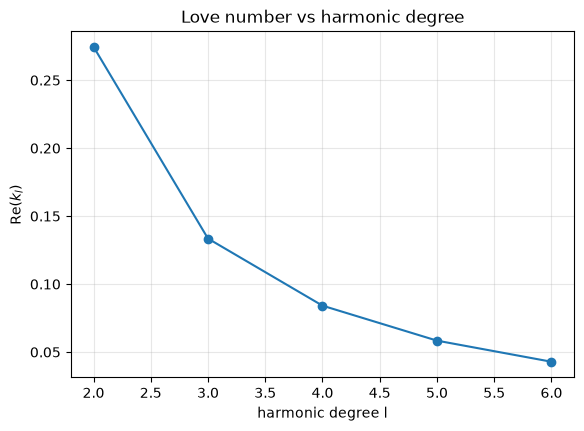

  l=2:  k = 0.2746
  l=3:  k = 0.1335
  l=4:  k = 0.0841
  l=5:  k = 0.0584
  l=6:  k = 0.0429


In [5]:
degrees = [2, 3, 4, 5, 6]
kl = []
for L in degrees:
    kL, *_ = solve_layers(radius, density, bulk, shear, freq, bulk_density,
                          types, (False, False), (False, False), upper, degree_l=L)
    kl.append(kL.real)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(degrees, kl, "o-")
ax.set_xlabel("harmonic degree l")
ax.set_ylabel(r"Re$(k_l)$")
ax.set_title("Love number vs harmonic degree")
ax.grid(alpha=0.3)
plt.show()
for L, v in zip(degrees, kl):
    print(f"  l={L}:  k = {v:.4f}")


## Recap

- The radial solver integrates a layered interior and returns the Love numbers `k`, `h`, `l`.
- The propagator-matrix engine handles the incompressible homogeneous limit and matches the analytic
  Kelvin result; the shooting engine handles general compressible, multi-layer interiors.
- Static and dynamic solutions agree across the tidal regime and separate only at very short periods, so
  the static approximation is normally safe.
- A convenience wrapper, `LayeredWorld.solve_love_numbers(frequency_rad_s=...)`, runs this same machinery
  on a built world and exposes `world.love_number_k` / `h` / `l`.

Next: **`09_tidal_heating_3d`** turns the Love-number response into a full 3D map of tidal heating.
